In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1

1. По теореме Байеса:

$$
p(\lambda\mid n) \propto p(n\mid\lambda)p(\lambda) = \lambda^n e^{-\lambda}
$$

Это соответствует гамма-распределению  $\mathrm{Gamma}(\alpha=n+1,\,\beta=1)$, с плотностью

$$
p(\lambda)=\frac{\beta^{\alpha}}{\Gamma(\alpha)}\lambda^{\alpha-1}e^{-\beta\lambda}
$$ 

2. После второго независимого наблюдения $m$ (за ту же единицу времени) общая правдоподобие: $\lambda^{n+m} e^{-2\lambda}$, поэтому апостериорная вероятность:

$$
p(\lambda\mid n,m)\propto \lambda^{n+m} e^{-2\lambda}
$$ 

Это гамма-распределение с параметрами $\alpha=n+m+1, \beta=2$: $\lambda\mid n,m\sim\mathrm{Gamma}(n+m+1,\,2)$

# 3

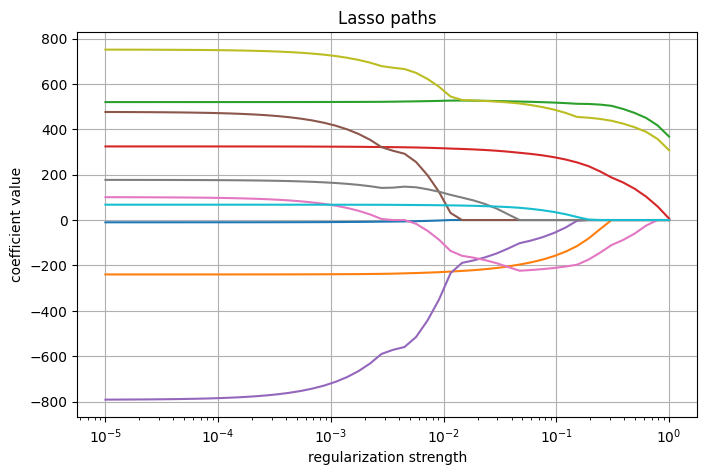

alpha= 0.001  nonzero coef= 10
alpha= 0.01  nonzero coef= 10
alpha= 0.1  nonzero coef= 7
alpha= 1.0  nonzero coef= 3


In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso

data, target = load_diabetes(return_X_y=True)
alphas = np.logspace(-5, 0, 50)
coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(data, target)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(8,5))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:,i], label=f'w{i}' if i<6 else None)
plt.xscale('log')
plt.xlabel('regularization strength')
plt.ylabel('coefficient value')
plt.title('Lasso paths')
plt.grid(True)
plt.show()

for a in [1e-3,1e-2,1e-1,1.0]:
    model = Lasso(alpha=a, max_iter=10000).fit(data, target)
    print('alpha=', a, ' nonzero coef=', np.sum(model.coef_!=0))


# 4

In [11]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

np.random.seed(0)
n_samples = 200
x = np.random.rand(n_samples)
y = np.sin(2*np.pi*x) + 0.3*np.random.randn(n_samples)

poly = PolynomialFeatures(5, include_bias=True)
X = poly.fit_transform(x.reshape(-1,1))

def l1_grad_descent(X, y, mu, lr, n_iters=1000):
    n, d = X.shape
    w = np.zeros(d)
    for it in range(n_iters):
        grad = 2.0/n * X.T.dot(X.dot(w) - y)
        subg = mu * np.sign(w)
        grad = grad + subg
        w = w - lr * grad
    return w

kf = KFold(5, shuffle=True, random_state=1)
mus = [0.0, 1e-3, 1e-2, 5e-2, 1e-1]
lrs = [1e-3, 5e-4, 2e-4]
results = {}
for mu in mus:
    for lr in lrs:
        val_scores = []
        for train_idx, val_idx in kf.split(X):
            w = l1_grad_descent(X[train_idx], y[train_idx], mu=mu, lr=lr, n_iters=2000)
            preds = X[val_idx].dot(w)
            val_scores.append(mean_squared_error(y[val_idx], preds))
        results[(mu,lr)] = np.mean(val_scores)

best = min(results, key=lambda k: results[k])
print('Best (mu, lr)=', best, 'CV MSE=', results[best])

w_best = l1_grad_descent(X, y, mu=best[0], lr=best[1], n_iters=5000)
print('Nonzero coefficients after GD with L1:', np.sum(np.abs(w_best)>1e-6))
print('Coefficients:', w_best)


Best (mu, lr)= (0.0, 0.001) CV MSE= 0.37101199731742834
Nonzero coefficients after GD with L1: 6
Coefficients: [ 0.47742207 -0.53605891 -0.51397734 -0.34350736 -0.18736438 -0.06873166]


# 3

Фиксируем выборку $ \{x_i\}_{i=1}^n$, распределенную нормально

$$
p(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

Рассмотрим логарифм правдоподобия:

$$
\ell(\mu, \sigma^2) = \log L(\mu, \sigma^2) = -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2
$$

Найдем максимум по $\mu$

$$
\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0
\quad \Rightarrow \quad
\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i
$$

Найдем максмум по $\sigma^2$

Подставим $\hat{\mu} = \bar{x}$ и обозначим $S = \sum_{i=1}^n (x_i - \bar{x})^2$:

$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{S}{2(\sigma^2)^2} = 0
\quad \Rightarrow \quad
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
$$

Таким образом:

$$
\boxed{
\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i, \quad
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2
}
$$